# Cross Sectional Portfolio

In [2]:
import os
import bt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [3]:
print(os.getcwd())

C:\Users\Diego\Documents\GitHub\CommodityForwardInflation


In [2]:
energy_tickers = ["CL", "CO", "HO", "NG", "QS", "XB"]
inf_tickers    = ["BCMPGBIF", "BCMPUSIF"]

In [3]:
data_path = r"A:\BBGData\data"
inf_paths = [os.path.join(data_path, ticker + ".parquet") for ticker in inf_tickers]
df_inf    = (pd.read_parquet(
    path = inf_paths, engine = "pyarrow").
    assign(country = lambda x: np.where(x.security.str.split(" ").str[0] == "BCMPGBIF", "UK", "US")))

In [7]:
fut_path   = r"A:\BBGFuturesManager_backup_backup\data\PXFront"
fut_paths  = [os.path.join(fut_path, ticker + ".parquet") for ticker in energy_tickers]
df_fut_rtn = (pd.read_parquet(
    path = fut_paths, engine = "pyarrow").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

In [9]:
df_inf_prep = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    diff().
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "inf_surp").
    dropna())

In [22]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_surp)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(lag_resid = lambda x: x.resid.shift()).
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

df_resid = (df_inf_prep.merge(
    right = df_fut_rtn, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    dropna())

In [25]:
df_px_raw = (pd.read_parquet(
    path = fut_paths, engine = "pyarrow").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    dropna())

In [41]:
def _get_leg(df: pd.DataFrame) -> pd.DataFrame: 

    try:
    
        df_out = (df.assign(
            group = lambda x: pd.qcut(x = x.resid, q = 2, labels = ["lower_group", "upper_group"])))

        return df_out

    except:
        pass

df_group = (df_resid.drop(
    columns = ["group_var"]).
    dropna().
    assign(group_var = lambda x: x.date.astype(str) + " " + x.country).
    groupby("group_var").
    apply(_get_leg, include_groups = False).
    reset_index(drop = True))

In [62]:
groups = df_group.country.drop_duplicates().sort_values().to_list()
for group in groups: 

    df_raw_selector = (df_group.query(
        "country == @group").
        pivot(index = "date", columns = "security", values = "group"))

    good_dates  = list(set(df_raw_selector.index.to_list()) & set(df_px_raw.index.to_list()))
    df_selector = df_raw_selector.query("date == @good_dates")
    df_px_input = df_px_raw.query("date == @good_dates")
    legs        = ["lower_group", "upper_group"]

    df_long_selector_input  = df_selector.apply(lambda x: x == "lower_group")
    df_short_selector_input = df_selector.apply(lambda x: x == "upper_group")

    long_strategy = (bt.Strategy(
        name     = "long_leg",
        algos    = [
            bt.algos.RunDaily(),
            bt.algos.SelectWhere(df_long_selector_input),
            bt.algos.WeighInvVol(
                lookback = pd.DateOffset(days = 100),
                lag      = pd.DateOffset(days = 1)),
            bt.algos.Rebalance()]))
    
    short_strategy = (bt.Strategy(
        name     = "short_leg",
        algos    = [
            bt.algos.RunDaily(),
            bt.algos.SelectWhere(df_short_selector_input),
            bt.algos.WeighInvVol(
                lookback = pd.DateOffset(days = 100),
                lag      = pd.DateOffset(days = 1)),
            bt.algos.Rebalance()]))

    combined_strat = (bt.Strategy(
        name  = "combined",
        algos = [
            bt.algos.RunDaily(),
            bt.algos.SelectAll(),
            bt.algos.WeighSpecified(**{
                "long_leg" : 0.5,
                "short_leg": -0.5}),
            bt.algos.Rebalance()],
        children = [long_strategy, short_strategy]))

    backtest = (bt.Backtest(
        integer_positions = False,
        strategy          = combined_strat,
        data              = df_px_input))
    break

In [64]:
tmp = bt.run(backtest)

  0%|                                                                                            | 0/1 [00:00<?, ?it/s]C:\Users\Diego\anaconda3\Lib\site-packages\bt\backtest.py:231: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  self.strategy.setup(self.data, **self.additional_data)
100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [04:26<00:00, 266.71s/it]


<Axes: >

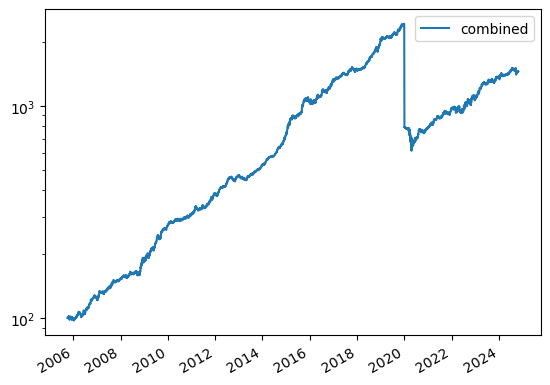

In [67]:
tmp.prices.plot(logy = True)